### Model training notebook

In [62]:
# Dataset
from pandas import read_csv
from numpy import sum
from seaborn import histplot
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# Sklearn intel extension
from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [63]:
# Read the training data
training_df = read_csv('../data/final_datasets/transformed_datasets/transformed_halfsigma_oversampled_training_data.csv')

# Read the test data
test_df = read_csv('../data/final_datasets/transformed_datasets/transformed_test_data.csv')

# Read the submission data
submission_df = read_csv('../data/initial_datasets/Submission_template_UHI2025-v2.csv')

In [64]:
# Separate predictors and responses
X = training_df.drop(columns = ['UHI Index']).values
y = training_df['UHI Index'].values

In [65]:
# Separate predictors and responses
X_test = test_df.values

In [144]:
# Generate array of weights
w = (abs(y - y.mean()))**2
w = w/sum(w)

In [66]:
# Train the Random Forest model on the training data
"""model = RandomForestRegressor(n_estimators = 256, 
                              criterion = 'squared_error',
                              ccp_alpha = 5.93279137e-20, 
                              max_features = 0.8, 
                              max_leaf_nodes = 2241,
                              min_samples_split = 0.00017239623972536324,
                              min_samples_leaf = 0.0006733944396699074, 
                              max_depth = 25,
                              random_state = 10)"""
"""model = XGBRegressor(nthread = -1, 
                     colsample_bylevel = 0.27089875569868677,
                     colsample_bynode = 0.00023871262162442934,
                     colsample_bytree = 0.2521310852858073,
                     eta = 0.16984948183848828,
                     gamma = 4.936495008750438e-07, 
                     max_depth = 9, 
                     min_child_weight = 1.1130829945563475e-06, 
                     reg_alpha = 0.00027764020436691245, 
                     reg_lambda = 0.11543156340963502, 
                     subsample = 0.6725418424266979, 
                     tree_method = 'auto',
                     random_state = 10)"""
model = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 4, 
                            p = 2, 
                            weights = 'distance')
"""model = RandomForestRegressor(n_estimators = 256, 
                            criterion = 'squared_error',
                            ccp_alpha = 5.93279137e-20, 
                            max_features = 0.8, 
                            max_leaf_nodes = 1900,
                            min_samples_split = 0.00017239623972536324,
                            min_samples_leaf = 0.0006733944396699074, 
                            max_depth = 20,
                            random_state = 10)"""
#model.fit(X, y, sample_weight = w)
model.fit(X, y)

KNeighborsRegressor(metric='manhattan', n_jobs=1, n_neighbors=4, p=1,
                    weights='distance')

In [6]:
#df_names = read_csv('../data/final_datasets/raw_datasets/raw_reduced_training_data.csv')
corr = training_df.corr(method = 'spearman')

columns_correlations_importances = []

for column, correlation, importance in zip(training_df.columns[:-1], corr['UHI Index'].values[:-1], model.feature_importances_):
    columns_correlations_importances.append([column, correlation, importance])
    
sorted_list = sorted(columns_correlations_importances, key = lambda x: x[2], reverse = False)

In [9]:
sorted_list

[['datt1_median_res10', -0.10108123020924105, 0.0004934911706585774],
 ['B2_median_res10', 0.17331527364580235, 0.000559598421404243],
 ['B4_median_res10', 0.1721538369503773, 0.0005609909856771687],
 ['ndmi_median_res10', -0.19692658420060125, 0.0006018082163679528],
 ['si_median_res10', 0.14768125141276878, 0.000637007618046989],
 ['w_median_res10', -0.13322188268910745, 0.000660883825843272],
 ['B3_median_res10', 0.1707866849907093, 0.0006704331872865408],
 ['B5_median_res10', 0.16861792634929842, 0.0011016853055231812],
 ['B7_median_res10', -0.10985123255260303, 0.0012143038041151767],
 ['B8_median_res10', -0.1322424711376458, 0.0012686324650149283],
 ['evi_median_res10', -0.20325645482723342, 0.0012909865550368236],
 ['B8A_median_res10', -0.12267888198808166, 0.0013026439267878967],
 ['siwsi_median_res10', -0.23756384399757405, 0.0013302705769911688],
 ['B4_median_res100', 0.35605485251068997, 0.0014702857071343881],
 ['gndvi_median_res10', -0.23242072169639502, 0.0015079866447078

In [ ]:
### Iterate over the different thresholds to test which set of dropped features gets the greatest training R^2
for th in [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]:
    # Set the cumulative sum of importances to 0
    sum = 0.0
    for i, row in enumerate(sorted_list):
        sum = sum + 100.0*row[2]
        if sum >= th:
            i_lim = i
            break

    # Set columns to roule out
    cols = []
    for row in sorted_list[:i_lim]:
        cols.append(row[0])
        
    # Set predictors to train the model
    X_tmp = training_df.drop(columns = cols + ['UHI Index'])
    
    # Split in training and test data
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(X_tmp, y, random_state=0, stratify=y)
    
    # Train the Random Forest model on the training data
    model_tmp = RandomForestRegressor(n_estimators = 256, 
                                      criterion = 'squared_error',
                                      ccp_alpha = 5.93279137e-20, 
                                      max_features = 0.8, 
                                      max_leaf_nodes = 1900,
                                      min_samples_split = 0.00017239623972536324,
                                      min_samples_leaf = 0.0006733944396699074, 
                                      max_depth = 20,
                                      random_state = 10)
    
    # Fit the model
    model_tmp.fit(X_train_tmp, y_train_tmp)
    
    # Make predictions on the training data
    train_predictions_tmp = model_tmp.predict(X_train_tmp)
    
    # Make predictions on the test data
    test_predictions_tmp = model_tmp.predict(X_test_tmp)
    
    # Calculate R-squared score for in-sample and test predictions
    train_r_squared = r2_score(y_train_tmp.tolist(), train_predictions_tmp)
    test_r_squared = r2_score(y_test_tmp.tolist(), test_predictions_tmp)
    
    print("Number of columns to drop {}. R^2 generated after dropping variables: Training {} | Test {}.".format(i_lim, train_r_squared, test_r_squared))

Number of columns to drop 11. R^2 generated after dropping variables: Training 0.9751162868136235 | Test 0.9383108456395249.
Number of columns to drop 18. R^2 generated after dropping variables: Training 0.9751796153598137 | Test 0.9395546103386122.
Number of columns to drop 22. R^2 generated after dropping variables: Training 0.9749450283865392 | Test 0.9397911769045172.
Number of columns to drop 25. R^2 generated after dropping variables: Training 0.9746219363571916 | Test 0.939132056206456.
Number of columns to drop 28. R^2 generated after dropping variables: Training 0.9747908746886855 | Test 0.940123300971851.
Number of columns to drop 30. R^2 generated after dropping variables: Training 0.9745933079225362 | Test 0.9393242023715239.
Number of columns to drop 33. R^2 generated after dropping variables: Training 0.9745010463678373 | Test 0.939360798295215.
Number of columns to drop 35. R^2 generated after dropping variables: Training 0.9743766613830744 | Test 0.9393686363645187.
Num

In [12]:
for row in sorted_list[:28]:
    print(row[0])

datt1_median_res10
B2_median_res10
B4_median_res10
ndmi_median_res10
si_median_res10
w_median_res10
B3_median_res10
B5_median_res10
B7_median_res10
B8_median_res10
evi_median_res10
B8A_median_res10
siwsi_median_res10
B4_median_res100
gndvi_median_res10
B11_median_res10
B12_median_res10
fs_median_res10
B3_median_res100
B5_median_res100
B2_median_res100
B3_median_res250
ndmi_median_res100
B12_median_res100
B12_median_res250
B4_median_res250
B7_median_res250
B11_median_res100


In [67]:
# Make predictions on the training data
insample_predictions = model.predict(X)

In [68]:
# calculate R-squared score for in-sample predictions
y_train = y.tolist()
r_squared = r2_score(y_train, insample_predictions)
print(r_squared)

1.0


- Submission 1: (RFR - full dataset) training $R^2 = 0.9863$
- Submission 2: (RFR - reduced dataset) training $R^2 = 0.9822$
- Submission 3: (RFR - reduced SMOTE dataset) training $R^2 = 0.9921$
- Submission 4: (RFR - reduced SMOTE dataset - n_stimators = 50) training $R^2 = 0.9915$
- Submission 5: (RFR - reduced dataset - n_stimators = 50) training $R^2 = 0.9811$
- Submission 6: (RFR - reduced dataset - n_estimators = 128, ccp_alpha = 5.0e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 8) training $R^2 = 0.3278$
- Submission 7: (RFR - reduced SMOTE dataset - n_estimators = 128, ccp_alpha = 5.0e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 8) training $R^2 = 0.6184$
- Submission 8: (RFR - complete reduced dataset - n_estimators = 128, ccp_alpha = 2.5e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 11) training $R^2 = 0.6834$
- Submission 9: (RFR - complete reduced SMOTE dataset - n_estimators = 128, ccp_alpha = 2.5e-7, max_features = 0.3, min_samples_leaf = 0.01, max_depth = 12) training $R^2 = 0.8516$
- Submission 10: (RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 1.3809434469711727e-07, max_features = 0.8, max_leaf_nodes = 176, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 15) training $R^2 = 0.9215$
- Submission 11: (RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 2241, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 25) training $R^2 = 0.9730$
- Submission 12: (XGBR - complete reduced 98imp dataset - nthread = -1, subsample = 0.5) training $R^2 = 0.9798$
- Submission 13: (square weighted RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 2241, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 25) training $R^2 = 0.9596$
- Submission 14: (cubic weighted RFR - complete reduced 98imp dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 2241, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 25) training $R^2 = 0.9397$
- Submission 15: (XGBR - complete reduced 98imp dataset - nthread = -1, colsample_bylevel = 0.27089875569868677, colsample_bynode = 0.00023871262162442934, colsample_bytree = 0.2521310852858073, eta = 0.16984948183848828, gamma = 4.936495008750438e-07, max_depth = 9, min_child_weight = 1.1130829945563475e-06, reg_alpha = 0.00027764020436691245, reg_lambda = 0.11543156340963502, subsample = 0.6725418424266979, tree_method = 'auto') training $R^2 = 0.9893$
- Submission 16: (KNNR - complete reduced 98imp dataset - weights = 'distance', n_neighbors = 5, leaf_size = 356, algorithm = 'kd_tree') training $R^2 = 1.0$
- Submission 17: (KNNR - complete reduced oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 18: (KNNR - complete reduced oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 7, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 19: (XGBR - complete reduced oversampled 98imp dataset - nthread = -1, colsample_bylevel = 0.27089875569868677, colsample_bynode = 0.00023871262162442934, colsample_bytree = 0.2521310852858073,
eta = 0.16984948183848828, gamma = 4.936495008750438e-07, max_depth = 9, min_child_weight = 1.1130829945563475e-06, reg_alpha = 0.00027764020436691245, reg_lambda = 0.11543156340963502, subsample = 0.6725418424266979, tree_method = 'auto') training $R^2 = 0.9732$
- Submission 20: (KNNR - complete reduced double oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 21: (KNNR - complete reduced 1sigma oversampled 98imp dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 22: (RFR - complete dataset - n_estimators = 256, criterion = 'squared_error', ccp_alpha = 5.93279137e-20, max_features = 0.8, max_leaf_nodes = 1900, min_samples_split = 0.00017239623972536324, min_samples_leaf = 0.0006733944396699074, max_depth = 20, random_state = 10) training $R^2 = 0.9739$
- Submission 23: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 24: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 5, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 25: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 6, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 26: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 27: (KNNR - complete dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 3, p = 2, weights = 'distance') training $R^2 = 1.0$
- Submission 28: (KNNR - complete half sigma oversampled dataset - algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 4, p = 2, weights = 'distance') training $R^2 = 1.0$

In [69]:
# Make predictions on the test data
predictions = model.predict(X_test)

<Axes: ylabel='Count'>

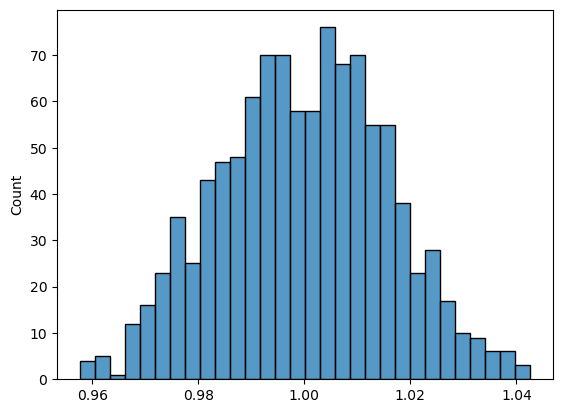

In [70]:
histplot(predictions, bins=30)

In [71]:
# Replace predictions of test data on submission dataset
submission_df['UHI Index'] = predictions

In [72]:
# Save the submission dataset
submission_df.to_csv('../data/submissions/submission-v28.csv', index = False)